In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mental_health_dataset.csv")

In [3]:
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,label
0,0,1,1,0,1,0,1,0,0,1,...,1,1,0,1,0,1,0,0,1,2
1,1,0,1,0,0,1,0,1,1,1,...,1,1,1,0,1,0,0,1,0,2
2,0,1,1,0,1,1,1,1,1,1,...,0,0,0,1,1,0,0,0,1,2
3,1,0,0,1,0,0,1,0,0,0,...,0,1,1,0,0,1,0,0,1,2
4,1,1,0,1,1,0,1,1,1,0,...,1,1,1,0,1,0,0,1,0,2


In [5]:
df["label"].value_counts()

label
2    1679
1     213
3     108
Name: count, dtype: int64

In [9]:
# !pip install imblearn
# from imblearn.over_sampling import SMOTE

In [8]:
from imblearn.over_sampling import SMOTE

In [12]:
y = df['label']
x = df.drop('label',axis=1)

In [13]:
x.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50
0,0,1,1,0,1,0,1,0,0,1,...,0,1,1,0,1,0,1,0,0,1
1,1,0,1,0,0,1,0,1,1,1,...,0,1,1,1,0,1,0,0,1,0
2,0,1,1,0,1,1,1,1,1,1,...,1,0,0,0,1,1,0,0,0,1
3,1,0,0,1,0,0,1,0,0,0,...,0,0,1,1,0,0,1,0,0,1
4,1,1,0,1,1,0,1,1,1,0,...,1,1,1,1,0,1,0,0,1,0


In [14]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: label, dtype: int64

In [15]:
sm = SMOTE(random_state=42)

In [17]:
x, y = sm.fit_resample(x, y)

In [19]:
y.value_counts()

label
2    1679
1    1679
3    1679
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

<Axes: >

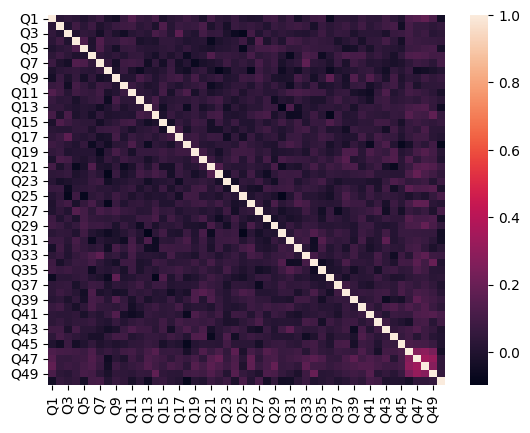

In [23]:
sns.heatmap(x_train.corr())

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [26]:
x_train

array([[-0.91931454,  1.16709096, -0.83700975, ..., -0.91003867,
         1.08892786,  1.24718899],
       [-0.91931454,  1.16709096, -0.83700975, ...,  1.09885441,
         1.08892786,  1.24718899],
       [ 1.08776698, -0.85683124, -0.83700975, ...,  1.09885441,
        -0.91833448, -0.8018031 ],
       ...,
       [-0.91931454, -0.85683124,  1.19472921, ..., -0.91003867,
        -0.91833448, -0.8018031 ],
       [-0.91931454,  1.16709096, -0.83700975, ..., -0.91003867,
         1.08892786,  1.24718899],
       [-0.91931454, -0.85683124, -0.83700975, ..., -0.91003867,
         1.08892786,  1.24718899]], shape=(3777, 50))

<Axes: >

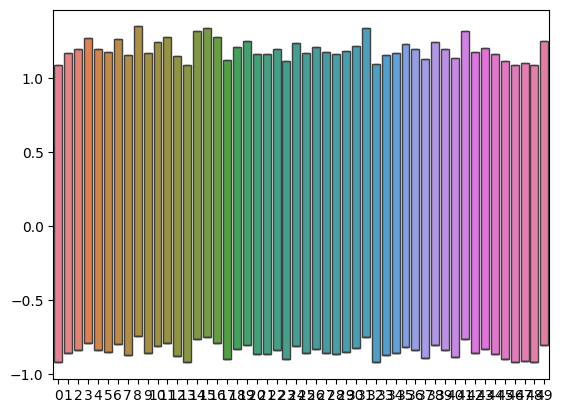

In [27]:
sns.boxplot(x_train)

In [24]:
from sklearn.linear_model import LogisticRegression

logi = LogisticRegression()

In [28]:
logi.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = logi.predict(x_test)

In [31]:
y_pred

array([3, 1, 1, ..., 3, 3, 1], shape=(1260,))

In [32]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score

In [34]:
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test, y_pred)

In [35]:
cm

array([[404,   3,   0],
       [  3, 341, 100],
       [  0,  68, 341]])

In [36]:
accuracy

0.861904761904762